## Functions

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

import h5py  
import seaborn as sns
from scipy.special import betaincinv
import scipy.stats as stats


from astropy.io import fits
from astropy.wcs import WCS
from astropy.nddata.utils import Cutout2D
from astropy.coordinates import SkyCoord
import astropy.units as u
from astropy.cosmology import Planck15  
from astropy.table import Table

import pdb
 
import torch
from typing import Optional, Tuple, Union
from torch import Tensor

import pickle
from operator import itemgetter

import os
import sys
sys.path.append(r"C:\Users\usuario\Documents\TFG\florah\src")

from florah.models.rnn_model.rnn_generator import DataModule 


#import sklearn
#import plotly.express as px


In [2]:
def build_roots_optimized(cosmos_cat, mass_bin, nsamples=100, zbins=[0, 0.5, 1], sample_fraction=0.3):
    """
    Optimized version of build_roots.
    Generates initial pairs of galaxies (root -> progenitor candidate), to initialize trees
    """
    
    # ---------------------------------------------------------
    # 1. Prepare data pools
    # ---------------------------------------------------------
    
    # Pool A: Roots (galaxies w redshift between zbins[0] y zbins[1], and mass in mass_bin)
    mask_roots = (
        (cosmos_cat['zpdf_med'] > zbins[0]) & 
        (cosmos_cat['zpdf_med'] < zbins[1]) & 
        (cosmos_cat['mass_CIGALE'] > mass_bin[0]) & 
        (cosmos_cat['mass_CIGALE'] < mass_bin[1])
    )
    pool_roots = cosmos_cat[mask_roots].copy()
    
    # Pool B: Choose progenitor candidates (galaxies w redshift between zbins[1] y zbins[2])
    # Note: We will filter mass later, because it will depend on each root's mass.
    mask_candidates = (
        (cosmos_cat['zpdf_med'] > zbins[1]) & 
        (cosmos_cat['zpdf_med'] < zbins[2])
    )
    pool_candidates = cosmos_cat[mask_candidates].copy()
    
    # If unable to find any galaxy (weird), return empty
    if pool_roots.empty or pool_candidates.empty:
        print("Advertencia: No se encontraron galaxias suficientes en los rangos de Z o Masa.")
        empty_out = {'x': [], 't': [], 'ra': [], 'dec': [], 'sersic': [], 'bovert': [], 'morphology': [], 'id': []}
        return empty_out, 0, []

    # ---------------------------------------------------------
    # 2. Root selection (w nsamples)
    # ---------------------------------------------------------
    if len(pool_roots) < nsamples:
        # If theres less roots in pool than nsamples, will take all but shuffled
        pool_roots = pool_roots.sample(frac=1)
    else:
        # If theres more, we will take only a number nsamples of roots
        pool_roots = pool_roots.sample(n=nsamples)
        
    n_roots = len(pool_roots)
    
    # ---------------------------------------------------------
    # 3. EXTRACCIÓN A NUMPY (VELOCIDAD MÁXIMA)
    # ---------------------------------------------------------
    # Convert DataFrames to dictionary of arrays for easy access
    # Roots
    r_mass = pool_roots['mass_CIGALE'].values
    r_sfr  = pool_roots['sfr_CIGALE'].values
    r_rad  = pool_roots['log_radius_kpc'].values
    r_z    = pool_roots['zpdf_med'].values
    r_ra   = pool_roots['ra'].values
    r_dec  = pool_roots['dec'].values
    r_ser  = pool_roots['sersic'].values
    r_bov  = pool_roots['bovert'].values
    r_mor  = pool_roots['morphology'].values
    r_id   = pool_roots['id'].values

    # Candidates
    c_mass = pool_candidates['mass_CIGALE'].values
    c_sfr  = pool_candidates['sfr_CIGALE'].values
    c_rad  = pool_candidates['log_radius_kpc'].values
    c_z    = pool_candidates['zpdf_med'].values
    c_ra   = pool_candidates['ra'].values
    c_dec  = pool_candidates['dec'].values
    c_sersic = pool_candidates['sersic'].values
    c_bovert = pool_candidates['bovert'].values
    c_morph = pool_candidates['morphology'].values
    c_id   = pool_candidates['id'].values

    # Store results in a list
    out = {k: [] for k in ['x', 't', 'ra', 'dec', 'sersic', 'bovert', 'morphology', 'id']}
    len_sel2_vec = []
    
    total_pairs = 0

    # ---------------------------------------------------------
    # 4. Main loop (iterate over each root)
    # ---------------------------------------------------------
    for i in range(n_roots):
        
        # Mass of current root
        current_mass = r_mass[i]
        
        # FILTER: Find candidates that fulfill mass condition
        # Condition: mass root - 1.5 < mass candidato < mass_root + 0.5
        mask_matches = (c_mass > (current_mass - 1.5)) & (c_mass < (current_mass + 0.5))
        
        # Index of those candidates that fulfill condition
        match_indices = np.where(mask_matches)[0]
        n_matches = len(match_indices)
        
        # FILTER: Sampling a fraction of those candidates (by default sample_fraction=0.03)
        if n_matches > 0:
            n_sample = int(n_matches * sample_fraction)
            
            if n_sample > 0:
                chosen_indices = np.random.choice(match_indices, size=n_sample, replace=False)
                
                # Create pairs (root -> candidate)
                # Iterate over the chosen candidates to build pairs
                for idx in chosen_indices:
                    # ROOTS
                    row0_x = [r_mass[i], r_rad[i], r_sfr[i]]
                    row0_t = [1.0 / (1.0 + r_z[i])]
                    row0_ra = [r_ra[i]]
                    row0_dec = [r_dec[i]]
                    row0_ser = [r_ser[i]]
                    row0_bov = [r_bov[i]]
                    row0_mor = [r_mor[i]]
                    row0_id = [r_id[i]]
                    
                    # Candidates
                    row1_x = [c_mass[idx], c_rad[idx], c_sfr[idx]]
                    row1_t = [1.0 / (1.0 + c_z[idx])]
                    row1_ra = [c_ra[idx]]
                    row1_dec = [c_dec[idx]]
                    row1_ser = [c_sersic[idx]]
                    row1_bov = [c_bovert[idx]]
                    row1_mor = [c_morph[idx]]
                    row1_id = [c_id[idx]]
                    
                    # vstack to create arrays of shape (2, N)
                    out['x'].append(np.array([row0_x, row1_x], dtype=np.float32))
                    out['t'].append(np.array([row0_t, row1_t], dtype=np.float32)) # Shape (2,1)
                    out['ra'].append(np.array([row0_ra, row1_ra], dtype=np.float32))
                    out['dec'].append(np.array([row0_dec, row1_dec], dtype=np.float32))
                    out['sersic'].append(np.array([row0_ser, row1_ser], dtype=np.float32))
                    out['bovert'].append(np.array([row0_bov, row1_bov], dtype=np.float32))
                    out['morphology'].append(np.array([row0_mor, row1_mor], dtype=np.float32))
                    out['id'].append(np.array([row0_id, row1_id], dtype=np.float32))
                    
                    total_pairs += 1
            
            len_sel2_vec.append(n_sample) # Store how many galaxies were sampled in each iteration
        else:
            len_sel2_vec.append(0)

    
    return out, n_roots, len_sel2_vec

In [3]:
def build_features_optimized(cosmos_cat, zbin, node_features, sample_fraction=0.003):
    """
    Optimized version of build_features.
    We find progenitors candidates in next zbin for a given galaxy with node_features
    """
    
    # 1. Filter: Galaxies within zbin
    mask_z = (cosmos_cat['zpdf_med'] > zbin[0]) & (cosmos_cat['zpdf_med'] < zbin[1])
    cosmos_slice = cosmos_cat[mask_z].copy()
    
    if cosmos_slice.empty:
        print("Did not find any galaxies in zbin specified.")
        # Return empty
        return {k: [] for k in node_features}, 0, [0]*len(node_features['x'])

    # Extract candidate columns to arrays
    c_mass = cosmos_slice['mass_CIGALE'].values
    c_sfr = cosmos_slice['sfr_CIGALE'].values
    c_rad = cosmos_slice['log_radius_kpc'].values
    c_z = cosmos_slice['zpdf_med'].values
    c_ra = cosmos_slice['ra'].values
    c_dec = cosmos_slice['dec'].values
    c_sersic = cosmos_slice['sersic'].values
    c_bovert = cosmos_slice['bovert'].values
    c_morph = cosmos_slice['morphology'].values
    c_id = cosmos_slice['id'].values

    # Dictionary to store output
    out = {k: [] for k in ['x', 't', 'ra', 'dec', 'sersic', 'bovert', 'morphology', 'id']}
    sel2_len_vec = [] # Aquí guardaremos el tamaño REAL de los hijos generados
    
    # Descendant data (anterior zbin)
    ids_in = node_features['id']
    xs_in = node_features['x']
    ts_in = node_features['t']
    ras_in = node_features['ra']
    decs_in = node_features['dec']
    sersics_in = node_features['sersic']
    boverts_in = node_features['bovert']
    morphs_in = node_features['morphology']
    
    n_chunks = len(xs_in)

    # 2. Main loop
    for i in range(n_chunks):
        
        mass_last = xs_in[i][-1, 0]
        
        # FILTER: Find candidates that fulfill mass condition
        # Condition: mass root - 1.5 < mass candidato < mass_root + 1.5
        mass_mask = np.abs(c_mass - mass_last) < 1.5
        candidate_indices = np.where(mass_mask)[0]
        n_candidates = len(candidate_indices)
        
        actual_prog_count = 0 
        
        # FILTER: Sampling a fraction of those candidates (by default sample_fraction=0.03)
        if n_candidates > 0:
            size_sample = int(n_candidates * sample_fraction)
            
            if size_sample > 0:
                # Choose index
                chosen_indices = np.random.choice(candidate_indices, size=size_sample, replace=False)
                actual_prog_count = len(chosen_indices)
                
                # Prepare descendant data (galaxy in anterior zbin)
                p_x = xs_in[i]
                p_t = ts_in[i]
                p_ra = ras_in[i]
                p_dec = decs_in[i]
                p_ser = sersics_in[i]
                p_bov = boverts_in[i]
                p_mor = morphs_in[i]
                p_id = ids_in[i]

                # Build branches
                for idx in chosen_indices:
                    new_row_x = np.array([c_mass[idx], c_rad[idx], c_sfr[idx]], dtype=np.float32)
                    new_row_t = np.array([1.0 / (1.0 + c_z[idx])], dtype=np.float32)
                    
                    new_row_ra = np.array([c_ra[idx]], dtype=np.float32)
                    new_row_dec = np.array([c_dec[idx]], dtype=np.float32)
                    new_row_ser = np.array([c_sersic[idx]], dtype=np.float32)
                    new_row_bov = np.array([c_bovert[idx]], dtype=np.float32)
                    new_row_mor = np.array([c_morph[idx]], dtype=np.float32)
                    new_row_id = np.array([c_id[idx]], dtype=np.float32)

                    out['x'].append(np.vstack([p_x, new_row_x]))
                    out['t'].append(np.vstack([p_t, new_row_t]))
                    out['ra'].append(np.vstack([p_ra, new_row_ra]))
                    out['dec'].append(np.vstack([p_dec, new_row_dec]))
                    out['sersic'].append(np.vstack([p_ser, new_row_ser]))
                    out['bovert'].append(np.vstack([p_bov, new_row_bov]))
                    out['morphology'].append(np.vstack([p_mor, new_row_mor]))
                    out['id'].append(np.vstack([p_id, new_row_id]))
        
        sel2_len_vec.append(actual_prog_count)

    return out, n_chunks, sel2_len_vec

In [4]:
def log_likelihood_obs_optimized(
        model: torch.nn.Module, 
        batch: Tuple[Tensor],
        to_numpy: bool = True,
        device: str = None
    ) -> Union[Tensor, np.ndarray]:
    """
    Calculate log-likelihood
    
    Evaluate a batch of trees generated previously to determine how likely are they according to
    trained model.

    Parameters
    ----------
    model : torch.nn.Module
        Recurrent model 
    batch : Tuple[Tensor]
        Data converted to tensor for the model

    to_numpy : bool, opcional
        If True, converts result from PyTorch tensor to NumPy array. (Default: True)
    device : str, opcional
        Device where to execute ('cpu' or 'cuda'). If None, will try to use GPU is available

    Returns
    -------
    lp : Union[Tensor, np.ndarray]
        Vector with log-likelihood values for each sequence evaluated.
    """
    
    # 1. Choose device (GPU vs CPU)
    if device is None:
        device = 'cuda' if torch.cuda.is_available() else 'cpu'
        
    model = model.to(device)

    # Move data to same device as model
    # (If model is in GPU and data is not, PyTorch fails)
    if isinstance(batch, (tuple, list)):
        batch = tuple(b.to(device) if isinstance(b, torch.Tensor) else b for b in batch)
    elif isinstance(batch, dict):
        batch = {k: v.to(device) if isinstance(v, torch.Tensor) else v for k, v in batch.items()}
    elif isinstance(batch, torch.Tensor):
        batch = batch.to(device)

    # 2. Optimized evaluation
    with torch.no_grad():
        lp = model.log_prob(batch, return_context=False)

    # 3. Convert to NumPy if solicited
    if to_numpy:
        # We use .cpu() first in case tensor was in gpu
        lp = lp.cpu().detach().numpy()

    return lp

In [5]:
def get_maxlike_descendant_final(l_numpy, node_features, num_chunks, chunk_size):
    """
    Optimized and final version of get_maxlike_descendant
    Choose progenitor with max likelihood 
    """
    
    # 1. Safety Check - Making sure l_numpy has same size as chunk_size
    total_hijos = np.sum(chunk_size)
    total_probs = len(l_numpy)
    

    # 1. DETERMINAR LA LONGITUD DE LA SECUENCIA
    # Si tenemos 25372 probs para 12686 hijos, seq_len es 2.
    if total_hijos > 0:
        seq_len = total_probs // total_hijos
        
        # 2. EXTRAER SOLO LA PROBABILIDAD FINAL DE CADA SECUENCIA
        # l_numpy viene como [P_hijo1_paso1, P_hijo1_paso2, P_hijo2_paso1, P_hijo2_paso2...]
        # Queremos los índices: seq_len - 1, (2*seq_len) - 1, etc.
        indices_finales = np.arange(total_hijos) * seq_len + (seq_len - 1)
        l_numpy_filtrado = l_numpy[indices_finales]
    else:
        l_numpy_filtrado = l_numpy

    # 3. VECTORIZACIÓN PARA ENCONTRAR EL MEJOR HIJO
    parent_ids = np.repeat(np.arange(num_chunks), chunk_size)
    
    # Create temporal DataFrame
    df = pd.DataFrame({
        'likelihood': l_numpy_filtrado,
        'parent_id': parent_ids,
        'global_index': np.arange(len(l_numpy_filtrado))
    })
    
    # Find the global index of max likelihood for each progenitor
    # idxmax gives us index for DF where max is
    best_indices = df.loc[df.groupby('parent_id')['likelihood'].idxmax(), 'global_index'].values
    best_indices.sort()

    # 3. Data extraction
    keys_to_extract = ['x', 't', 'ra', 'dec', 'sersic', 'bovert', 'morphology', 'id']
    node_features_updated = {}

    for key in keys_to_extract:
        original_list = node_features[key]
        # Selecting winning indices
        selected_items = [original_list[i] for i in best_indices]
        node_features_updated[key] = selected_items

    return node_features_updated

## Load data and model

In [6]:
# Load the trained model from a checkpoint file
checkpoint_path = "C:\\Users\\usuario\\Documents\\TFG\\florah_training_SFR\\last-v1.ckpt"  # Specify the path to your checkpoint file
loaded_model = DataModule.load_from_checkpoint(checkpoint_path,map_location='cpu', weights_only=False)


# Set the model to evaluation mode (important if you have dropout or batch normalization layers)
loaded_model.eval()

DataModule(
  (model): RecurrentMAF(
    (embedding_net): Identity()
    (rnn): ModuleList(
      (0): GRU(5, 128, batch_first=True)
      (1-3): 3 x GRU(128, 128, batch_first=True)
    )
    (maf_blocks): Flow(
      (_transform): CompositeTransform(
        (_transforms): ModuleList(
          (0): CompositeTransform(
            (_transforms): ModuleList(
              (0-3): 4 x CompositeTransform(
                (_transforms): ModuleList(
                  (0): MaskedAffineAutoregressiveTransform(
                    (autoregressive_net): MADE(
                      (initial_layer): MaskedLinear(in_features=3, out_features=128, bias=True)
                      (context_layer): Linear(in_features=128, out_features=128, bias=True)
                      (blocks): ModuleList(
                        (0-1): 2 x MaskedFeedforwardBlock(
                          (batch_norm): BatchNorm1d(128, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
                          (line

In [7]:
cosmos_data_path = "C:\\Users\\usuario\\Documents\\TFG\\florah_training_SFR\\"
cosmos_cat = pd.read_csv(cosmos_data_path+"COSMOSWeb_Laura_processed.csv") # Data from COSMOS-WEB, converted from .fits to .csv in florah_eval_SFR.ipynb

In the next sections we need to choose between running the algorithm that gives us progenitor-descendant relations locally or in deimos. 
Note that paths for both these options are different, due to keeping separated runs from deimos and from my local machine.

#### **Option 1:** Run locally

In [ ]:
nfm_data_path = "C:\\Users\\usuario\\Documents\\TFG\\likelihood_COSMOS_SFR\\node_features_morphology\\" # Path to local runs
datos2_data_path = 'C:\\Users\\usuario\\Documents\\TFG\\likelihood_COSMOS_SFR\\datos2\\'
datos1_data_path = 'C:\\Users\\usuario\\Documents\\TFG\\likelihood_COSMOS_SFR\\datos1\\'

Next cell predicts progenitor-descendant relations.

In [ ]:
redshifts = np.array([1.,1.5,2,2.5,3.5,4.5,6])
mass_bin=[[9.8,10]]
#mass_bin = [[9.8,10],[10,10.2],[10.2,10.4],[10.4,10.6],[10.6,10.8],[10.8,11],[11,12]]

for m in mass_bin:
    print('Iteracion mass_bin: ', m)
    # First we build root and find best candidate for progenitor in next redshift bin
    node_features, n_chunks, chunk_size = build_roots_optimized(cosmos_cat, m, nsamples=100) # Select root in zbin = (0, 0.5) + candidate for progenitor in zbin = (0.5, 1)
    preprocessed_node_features = loaded_model.transform(node_features, fit=False) 
    l  = log_likelihood_obs_optimized(loaded_model,preprocessed_node_features) # Calculate likelihood for every pair
    node_features = get_maxlike_descendant_final(l,node_features,n_chunks,chunk_size) # Chooses the galaxy with higher likelihood

    # Loop to find progenitors in the following bins
    for zmin,zmax in zip(redshifts[:-1],redshifts[1:]):
        print('Iteracion zbin: ', zmin, zmax)
        node_features,n_chunks,chunk_size = build_features_optimized(cosmos_cat,[zmin,zmax],node_features)
        preprocessed_node_features = loaded_model.transform(node_features, fit=False)
        l  = log_likelihood_obs_optimized(loaded_model, preprocessed_node_features)
        node_features = get_maxlike_descendant_final(l,node_features, n_chunks, chunk_size)
        
# Store node_features
    with open(nfm_data_path+'node_features_morphology'+str(m[0])+'_'+str(m[1])+'.pkl', 'wb') as outfile:
        pickle.dump(node_features, outfile)

#### **Option 2:** Run in deimos

In [8]:
dir = "fraction_1" # change to the dir containing especific run you want to plot

nfm_data_path = rf"C:\Users\usuario\Documents\TFG\likelihood_COSMOS_SFR\deimos\{dir}\node_features_morphology\\" #path to deimos runs
datos1_data_path = rf"C:\Users\usuario\Documents\TFG\likelihood_COSMOS_SFR\deimos\{dir}\datos1\\"
datos2_data_path = rf"C:\Users\usuario\Documents\TFG\likelihood_COSMOS_SFR\deimos\{dir}\datos2\\"
plots_path = rf"C:\Users\usuario\Documents\TFG\likelihood_COSMOS_SFR\deimos\{dir}\plots\\"


### Upload data

In [9]:
file_list = []
mass_bin = [[9.8, 10], [10, 10.2], [10.2, 10.4], [10.4, 10.6], [10.6, 10.8], [10.8, 11], [11, 12]]

# Generate the list of file names based on node_features['id']
for m_bin in mass_bin:
    # Load node_features for the current mass bin
    with open(os.path.join(nfm_data_path, f'node_features_morphology{m_bin[0]}_{m_bin[1]}.pkl'), 'rb') as infile:
        node_features = pickle.load(infile)

In [10]:
# Iterate through the entries in the structure
for i in range(len(node_features['x'])):
    df = pd.DataFrame({
        'id': node_features['id'][i][:, 0],
        'x_mass': node_features['x'][i][:, 0],  # Assuming x_mass is the first column of x
        'x_size': node_features['x'][i][:, 1],  # Assuming x_size is the second column of x
        'x_SFR': node_features['x'][i][:, 2],  # Assuming x_sfr is the second column of x
        't': node_features['t'][i][:, 0],
        'ra': node_features['ra'][i][:, 0],
        'dec': node_features['dec'][i][:, 0],
        'sersic': node_features['sersic'][i][:, 0],
        'bovert': node_features['bovert'][i][:, 0],
        'morphology': node_features['morphology'][i][:, 0]
    })

    # Get the values for constructing the file name
    ra_val = node_features['ra'][i][0][0]
    dec_val = node_features['dec'][i][0][0]

    # Construct the file name
    file_name = f"COSMOS_{ra_val}_{dec_val}.csv"

    # Save the DataFrame as a CSV file
    df.to_csv(datos1_data_path+file_name, index=False)


## Data analysis

### graficas chiquitas

In [ ]:
def plot_mass_evolution(node_features, num_trees=20):
    plt.figure(figsize=(10, 6))
    
    # Tomamos una muestra de árboles
    n_total = len(node_features['x'])
    indices = np.random.choice(n_total, min(num_trees, n_total), replace=False)
    indices = range(num_trees)

    for i in indices:
        # Extraemos masa y factor de escala
        # Usamos .flatten() para asegurar que sean arrays de 1D
        masa = np.array(node_features['x'][i]).flatten()
        a = np.array(node_features['t'][i]).flatten()
        
        # Si la masa tiene más columnas (ej. masa, radio, SFR), 
        # nos aseguramos de coger solo la primera (masa)
        if masa.ndim > 1 or len(masa) > len(a):
             masa = np.array(node_features['x'][i])[:, 0]

        z = (1.0 / a) - 1.0
        
        # Extraemos el ID de forma segura para el label
        try:
            # Intentamos sacar el primer elemento del ID y convertirlo a entero
            galaxy_id = int(np.array(node_features['id'][i]).flatten()[0])
        except:
            galaxy_id = i # Si falla, usamos el índice de la lista

        plt.plot(z, masa, marker='o', linestyle='-', alpha=0.8, label=f'ID: {galaxy_id}')

    # Estética de la gráfica
    plt.xlabel('Redshift ($z$)', fontsize=12)
    plt.ylabel(r'Stellar Mass $\log_{10}(M_* / M_{\odot})$', fontsize=12)
    plt.title('Stellar mass evolution', fontsize=14)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend(title="Tree roots", bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.savefig(plots_path+'log_mass_evolution_branches.png')
    plt.show()
    

# Llamada a la función
plot_mass_evolution(node_features)

In [ ]:
def plot_radius_evolution(node_features, num_trees=20):
    plt.figure(figsize=(10, 6))
    
    # Tomamos una muestra de árboles
    n_total = len(node_features['x'])
    indices = np.random.choice(n_total, min(num_trees, n_total), replace=False)
    indices = range(num_trees)

    for i in indices:
        # Extraemos datos
        # Usamos .flatten() para asegurar que sean arrays de 1D
        a = np.array(node_features['t'][i]).flatten()
        re = np.array(node_features['x'][i])[:, 1]
        z = (1.0 / a) - 1.0
        
        # Extraemos el ID de forma segura para el label
        try:
            # Intentamos sacar el primer elemento del ID y convertirlo a entero
            galaxy_id = int(np.array(node_features['id'][i]).flatten()[0])
        except:
            galaxy_id = i # Si falla, usamos el índice de la lista

        plt.plot(z, re, marker='o', linestyle='-', alpha=0.8, label=f'ID: {galaxy_id}')

    # Estética de la gráfica
    plt.xlabel('Redshift ($z$)', fontsize=12)
    plt.ylabel(r'Galaxy radius $\log_{10}(z \cdot R_e)$', fontsize=12)
    plt.title('Galaxy radius evolution evolution', fontsize=14)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend(title="Tree roots", bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.savefig(plots_path+'log_radius_evolution_branches.png')
    plt.show()

# Llamada a la función
plot_radius_evolution(node_features)


In [ ]:
def plot_sfr_evolution(node_features, num_trees=20):
    plt.figure(figsize=(10, 6))
    
    # Tomamos una muestra de árboles
    n_total = len(node_features['x'])
    indices = np.random.choice(n_total, min(num_trees, n_total), replace=False)
    indices = range(num_trees)

    for i in indices:
        # Extraemos datos
        # Usamos .flatten() para asegurar que sean arrays de 1D
        a = np.array(node_features['t'][i]).flatten()
        sfr = np.array(node_features['x'][i])[:, 2]
        z = (1.0 / a) - 1.0
        
        # Extraemos el ID de forma segura para el label
        try:
            # Intentamos sacar el primer elemento del ID y convertirlo a entero
            galaxy_id = int(np.array(node_features['id'][i]).flatten()[0])
        except:
            galaxy_id = i # Si falla, usamos el índice de la lista

        plt.plot(z, sfr, marker='o', linestyle='-', alpha=0.8, label=f'ID: {galaxy_id}')

    # Estética de la gráfica
    plt.xlabel('Redshift ($z$)', fontsize=12)
    plt.ylabel(r'Stellar formation rate $\log_{10}(SFR)$', fontsize=12)
    plt.title('Galaxy stellar formation rate evolution', fontsize=14)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend(title="Tree roots", bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.savefig(plots_path+'log_sfr_evolution_branches.png')
    plt.show()

# Llamada a la función
plot_sfr_evolution(node_features)


### graficas grandes

In [ ]:
plt.figure(figsize=[10, 6])

all_sfrs = []
all_redshifts = []

for i in range(22):  # Assuming you have 20 entries based on your example
    redshifts = 1 / np.array(node_features['t'][i]) - 1
    sfr = np.array(node_features['x'][i][:, 2])
    plt.plot(redshifts, sfr, color='gray', alpha=0.3)

    all_redshifts.extend(redshifts)
    all_sfrs.extend(sfr)

# Make sure the data is in the correct numpy array format
all_redshifts_np = np.squeeze(np.array(all_redshifts))
all_sfrs_np = np.array(all_sfrs)

valid_data_mask = ~np.isnan(all_redshifts_np) & ~np.isnan(all_sfrs_np)
filtered_redshifts = all_redshifts_np[valid_data_mask]
filtered_sfrs = all_sfrs_np[valid_data_mask]

# Verify shapes
print("Shapes:", all_redshifts_np.shape, all_sfrs_np.shape)

# Binning the data
bin_edges = np.array([0,0.5,1.,1.5,2,2.5,3.5,4.5,6])
bin_means, bin_edges, _ = stats.binned_statistic(filtered_redshifts, filtered_sfrs, statistic='mean', bins=bin_edges)
bin_stds, _, _ = stats.binned_statistic(filtered_redshifts, filtered_sfrs, statistic='std', bins=bin_edges)
bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

plt.plot(bin_centers, bin_means, color='red')
plt.fill_between(bin_centers, bin_means - bin_stds, bin_means + bin_stds, color='red', alpha=0.3)


# Estética de la gráfica
plt.xlabel('Redshift ($z$)', fontsize=12)
plt.ylabel(r'Stellar formation rate $\log_{10}(SFR)$', fontsize=12)
plt.title('Galaxy stellar formation rate evolution', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig(plots_path+'log_sfr_evolution_modified.png')
plt.show()



In [ ]:
# Plot example for every mass bin
bin_edges = np.array([0, 0.5, 1., 1.5, 2, 2.5, 3.5, 4.5, 6])
mass_bin = [[9.8, 10], [10, 10.2], [10.2, 10.4], [10.4, 10.6], [10.6, 10.8], [10.8, 11], [11, 12]]

colors = ['red', 'orange', 'green', 'dodgerblue', 'purple', 'hotpink', 'brown']  # Adjust or add more colors for each mass bin

plt.figure(figsize=[8, 8])
plt.tick_params(axis='both', which='major', labelsize=20)

# Loop through each mass bin and corresponding color
for m_bin, color in zip(mass_bin, colors):
    # Load node_features for the current mass bin
    with open(nfm_data_path+f'node_features_morphology{m_bin[0]}_{m_bin[1]}.pkl', 'rb') as infile:
        node_features = pickle.load(infile)
        
    all_sfrs = []
    all_redshifts = []

    # Assuming 'n_chunks' is the total number of entries for node_features['t']
    for i in range(len(node_features['t'])):
        redshifts = 1 / np.array(node_features['t'][i]) - 1
        sfr = np.array(node_features['x'][i][:, 2])
        #plt.plot(redshifts, sfr, color=color, alpha=0.2)  # Use the same color for individual lines, with some alpha

        all_redshifts.extend(redshifts)
        all_sfrs.extend(sfr)

    # Processing for binned statistics
    all_redshifts_np = np.squeeze(np.array(all_redshifts))
    all_sfrs_np = np.array(all_sfrs)

    # Filtering valid data
    valid_data_mask = ~np.isnan(all_redshifts_np) & ~np.isnan(all_sfrs_np)
    filtered_redshifts = all_redshifts_np[valid_data_mask]
    filtered_sfrs = all_sfrs_np[valid_data_mask]

    # Binning the data
    bin_means, _, _ = stats.binned_statistic(filtered_redshifts, filtered_sfrs, statistic='mean', bins=bin_edges)
    bin_stds, _, _ = stats.binned_statistic(filtered_redshifts, filtered_sfrs, statistic='std', bins=bin_edges)
    bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

    # Plotting mean and std deviation
    plt.plot(bin_centers, bin_means, color=color, label=rf"$\log_{10}(M_* / M_\odot):$ ({m_bin[0]}-{m_bin[1]})",lw=4)
    plt.fill_between(bin_centers, bin_means - bin_stds, bin_means + bin_stds, color=color, alpha=0.3)


# Estética de la gráfica
plt.xlabel('Redshift ($z$)', fontsize=12)
plt.ylabel(r'Stellar formation rate $\log_{10}(SFR)$', fontsize=12)
plt.legend(loc='lower right')
plt.title('Galaxy stellar formation rate evolution', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig(plots_path+'log_sfr_ev_massbin.png')
plt.show()





In [ ]:
# Define your redshift bins and mass bins
nbins=12
bin_edges = np.array([0, 0.5, 1., 1.5, 2, 2.5, 3.5, 4.5, 6])
mass_bin = [[9.8,10],[10,10.2],[10.2,10.4],[10.4,10.6],[10.6,10.8],[10.8,11],[11,12]]

colors = ['red', 'orange', 'green', 'blue', 'purple', 'hotpink', 'brown']  # Adjust or add more colors for each mass bin 

plt.figure(figsize=[8, 8])
plt.tick_params(axis='both', which='major', labelsize=20)

# Loop through each mass bin and corresponding color
for m_bin, color in zip(mass_bin, colors):
    # Load node_features for the current mass bin
    with open(nfm_data_path+f'node_features_morphology{m_bin[0]}_{m_bin[1]}.pkl', 'rb') as infile:
        node_features = pickle.load(infile)
        
    all_sfrs = []
    all_redshifts = []
   

    # Assuming 'n_chunks' is the total number of entries for node_features['t']
    for i in range(len(node_features['t'])):
        redshifts = 1 / np.array(node_features['t'][i]) - 1
        t = np.array(node_features['t'][i])
        cosmic_times = Planck15.age(redshifts)
        sfr = 10**np.array(node_features['x'][i][:, 2])
        #plt.plot(redshifts, sfr, color=color, alpha=0.2)  # Use the same color for individual lines, with some alpha

        all_redshifts.extend(cosmic_times)
        all_sfrs.extend(sfr)

    # Processing for binned statistics
    all_redshifts_np = np.squeeze(np.array(all_redshifts))
    all_sfrs_np = np.array(all_sfrs)

    # Filtering valid data
    valid_data_mask = ~np.isnan(all_redshifts_np) & ~np.isnan(all_sfrs_np)
    filtered_redshifts = all_redshifts_np[valid_data_mask]
    filtered_sfrs = all_sfrs_np[valid_data_mask]

    # Binning the data
    bin_means, bin_edges, _ = stats.binned_statistic(filtered_redshifts, filtered_sfrs, statistic='mean', bins=nbins)
    bin_stds, _, _ = stats.binned_statistic(filtered_redshifts, filtered_sfrs, statistic='std', bins=nbins)
    bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

    # Plotting mean and std deviation
    plt.plot(bin_centers, bin_means, color=color, label=rf"$\log_{10}(M_* / M_\odot):$ ({m_bin[0]}-{m_bin[1]})",lw=4)
    plt.fill_between(bin_centers, bin_means - bin_stds, bin_means + bin_stds, color=color, alpha=0.3)

# Finalizing the plot



# Estética de la gráfica
plt.xlabel('Cosmic Time [$Gyr$]', fontsize=12)
plt.ylabel(r'SFR ($M_\odot \cdot yr^{-1}$)', fontsize=12)
plt.legend(loc='upper left')
plt.title('Galaxy stellar formation rate evolution', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig(plots_path+'sfr_ev_massbin.png')
plt.show()



In [ ]:
# Define your redshift bins and mass bins
bin_edges = np.array([0, 0.5, 1., 1.5, 2, 2.5, 3.5, 4.5, 6])
#mass_bin = [[10, 10.3], [10.3, 10.6], [10.6, 10.9], [11, 12]]
mass_bin = [[9.8,10],[10,10.2],[10.2,10.4],[10.4,10.6],[10.6,10.8],[10.8,11],[11,12]]

colors = ['red', 'orange', 'green', 'blue', 'purple', 'hotpink', 'brown']  # Adjust or add more colors for each mass bin 

plt.figure(figsize=[8, 8])
plt.tick_params(axis='both', which='major', labelsize=20)

# Loop through each mass bin and corresponding color
for m_bin, color in zip(mass_bin, colors):
    # Load node_features for the current mass bin
    with open(nfm_data_path+f'node_features_morphology{m_bin[0]}_{m_bin[1]}.pkl', 'rb') as infile:
        node_features = pickle.load(infile)
        
    all_sfrs = []
    all_redshifts = []

    # Assuming 'n_chunks' is the total number of entries for node_features['t']
    for i in range(len(node_features['t'])):
        redshifts = 1 / np.array(node_features['t'][i]) - 1
        sfr = np.array(node_features['x'][i][:, 0])
        
        #plt.plot(redshifts, sfr, color=color, alpha=0.2)  # Use the same color for individual lines, with some alpha

        all_redshifts.extend(redshifts)
        all_sfrs.extend(sfr)

    # Processing for binned statistics
    all_redshifts_np = np.squeeze(np.array(all_redshifts))
    all_sfrs_np = np.array(all_sfrs)

    # Filtering valid data
    valid_data_mask = ~np.isnan(all_redshifts_np) & ~np.isnan(all_sfrs_np)
    filtered_redshifts = all_redshifts_np[valid_data_mask]
    filtered_sfrs = all_sfrs_np[valid_data_mask]

    # Binning the data
    bin_means, _, _ = stats.binned_statistic(filtered_redshifts, filtered_sfrs, statistic='mean', bins=bin_edges)
    bin_stds, _, _ = stats.binned_statistic(filtered_redshifts, filtered_sfrs, statistic='std', bins=bin_edges)
    bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

    # Plotting mean and std deviation
    plt.plot(bin_centers, bin_means, color=color, label=rf"$\log_{10}(M_* / M_\odot):$ ({m_bin[0]}-{m_bin[1]})",lw=4)
    plt.fill_between(bin_centers, bin_means - bin_stds, bin_means + bin_stds, color=color, alpha=0.3)



# Estética de la gráfica
plt.xlabel('Redshift ($z$)', fontsize=12)
plt.ylabel(r'Stellar Mass $\log_{10}(M_* / M_{\odot})$', fontsize=12)
plt.legend(loc='lower left')
plt.title('Stellar mass evolution', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig(plots_path+'log_mass_ev_massbin.png')
plt.show()

In [ ]:
# Define your redshift bins and mass bins
bin_edges = np.array([0, 0.5, 1., 1.5, 2, 2.5, 3.5, 4.5, 6])
#mass_bin = [[10, 10.3], [10.3, 10.6], [10.6, 10.9], [11, 12]]
mass_bin = [[9.8,10],[10,10.2],[10.2,10.4],[10.4,10.6],[10.6,10.8],[10.8,11],[11,12]]

colors = ['red', 'orange', 'green', 'blue', 'purple', 'hotpink', 'brown']  # Adjust or add more colors for each mass bin 

plt.figure(figsize=[8, 8])
plt.tick_params(axis='both', which='major', labelsize=20)

# Loop through each mass bin and corresponding color
for m_bin, color in zip(mass_bin, colors):
    # Load node_features for the current mass bin
    with open(nfm_data_path+f'node_features_morphology{m_bin[0]}_{m_bin[1]}.pkl', 'rb') as infile:
        node_features = pickle.load(infile)
        
    all_sfrs = []
    all_redshifts = []

    # Assuming 'n_chunks' is the total number of entries for node_features['t']
    for i in range(len(node_features['t'])):
        redshifts = 1 / np.array(node_features['t'][i]) - 1
        sfr = np.array(node_features['sersic'][i])
        
        #plt.plot(redshifts, sfr, color=color, alpha=0.2)  # Use the same color for individual lines, with some alpha

        all_redshifts.extend(redshifts)
        all_sfrs.extend(sfr)

    # Processing for binned statistics
    all_redshifts_np = np.squeeze(np.array(all_redshifts))
    all_sfrs_np = np.squeeze(np.array(all_sfrs))

    # Filtering valid data
    valid_data_mask = ~np.isnan(all_redshifts_np) & ~np.isnan(all_sfrs_np)
    filtered_redshifts = all_redshifts_np[valid_data_mask]
    filtered_sfrs = all_sfrs_np[valid_data_mask]

    # Binning the data
    bin_means, _, _ = stats.binned_statistic(filtered_redshifts, filtered_sfrs, statistic='mean', bins=bin_edges)
    bin_stds, _, _ = stats.binned_statistic(filtered_redshifts, filtered_sfrs, statistic='std', bins=bin_edges)
    bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

    # Plotting mean and std deviation
    plt.plot(bin_centers, bin_means, color=color, label=rf"$\log_{10}(M_* / M_\odot):$ ({m_bin[0]}-{m_bin[1]})",lw=4)
    plt.fill_between(bin_centers, bin_means - bin_stds, bin_means + bin_stds, color=color, alpha=0.3)

# Finalizing the plot
plt.xlabel('Redshift ($z$)', fontsize=12)
plt.ylabel('Sersic index', fontsize=12)
plt.legend(loc='upper right')
plt.title('Sersic index evolution', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig(plots_path+'sersic_idx_growth_massbin.png')
plt.show()


In [ ]:
# Define your redshift bins and mass bins
bin_edges = np.array([0, 0.5, 1., 1.5, 2, 2.5, 3.5, 4.5, 6])
#mass_bin = [[10, 10.3], [10.3, 10.6], [10.6, 10.9], [11, 12]]
mass_bin = [[9.8,10],[10,10.2],[10.2,10.4],[10.4,10.6],[10.6,10.8],[10.8,11],[11,12]]

colors = ['red', 'orange', 'green', 'blue', 'purple', 'hotpink', 'brown']  # Adjust or add more colors for each mass bin 

plt.figure(figsize=[8, 8])
plt.tick_params(axis='both', which='major', labelsize=20)

# Loop through each mass bin and corresponding color
for m_bin, color in zip(mass_bin, colors):
    # Load node_features for the current mass bin
    with open(nfm_data_path+f'node_features_morphology{m_bin[0]}_{m_bin[1]}.pkl', 'rb') as infile:
        node_features = pickle.load(infile)
        
    all_sfrs = []
    all_redshifts = []

    # Assuming 'n_chunks' is the total number of entries for node_features['t']
    for i in range(len(node_features['t'])):
        redshifts = 1 / np.array(node_features['t'][i]) - 1
        cosmic_times = Planck15.age(redshifts)
        sfr = np.array(node_features['x'][i][:, 0])
        #plt.plot(redshifts, sfr, color=color, alpha=0.2)  # Use the same color for individual lines, with some alpha

        all_redshifts.extend(cosmic_times)
        all_sfrs.extend(sfr)

    # Processing for binned statistics
    all_redshifts_np = np.squeeze(np.array(all_redshifts))
    all_sfrs_np = np.array(all_sfrs)

    # Filtering valid data
    valid_data_mask = ~np.isnan(all_redshifts_np) & ~np.isnan(all_sfrs_np)
    filtered_redshifts = all_redshifts_np[valid_data_mask]
    filtered_sfrs = all_sfrs_np[valid_data_mask]

    # Binning the data
    bin_means, bin_edges, _ = stats.binned_statistic(filtered_redshifts, filtered_sfrs, statistic='mean', bins=nbins)
    bin_stds, _, _ = stats.binned_statistic(filtered_redshifts, filtered_sfrs, statistic='std', bins=nbins)
    bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

    # Plotting mean and std deviation
    plt.plot(bin_centers, bin_means, color=color, label=rf"$\log_{10}(M_* / M_\odot):$ ({m_bin[0]}-{m_bin[1]})",lw=4)
    plt.fill_between(bin_centers, bin_means - bin_stds, bin_means + bin_stds, color=color, alpha=0.3)

# Finalizing the plot
plt.xlabel('Cosmic time ($Gyrs$)', fontsize=12)
plt.ylabel(r'Stellar mass $\log_{10}(M_* / M_{\odot})$', fontsize=12)
plt.legend(loc='lower right')




plt.title('Stellar mass evolution', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig(plots_path+'log_mass_ev_cosmicyears_massbin.png')
plt.show()



In [ ]:
# Define your redshift bins and mass bins
nbins=10
#bin_edges = np.array([0, 0.5, 1., 1.5, 2, 2.5, 3.5, 4.5, 6])
#mass_bin = [[10, 10.3], [10.3, 10.6], [10.6, 10.9], [11, 12]]
#colors = ['blue', 'green', 'purple', 'orange']  # Adjust or add more colors for each mass bin
mass_bin = [[9.8,10],[10,10.2],[10.2,10.4],[10.4,10.6],[10.6,10.8],[10.8,11],[11,12]]
colors = ['red', 'orange', 'green', 'blue', 'purple', 'hotpink', 'brown']  # Adjust or add more colors for each mass bin 

plt.figure(figsize=[8, 8])
plt.tick_params(axis='both', which='major', labelsize=20)

# Loop through each mass bin and corresponding color
for m_bin, color in zip(mass_bin, colors):
    # Load node_features for the current mass bin
    with open(nfm_data_path+f'node_features_morphology{m_bin[0]}_{m_bin[1]}.pkl', 'rb') as infile:
        node_features = pickle.load(infile)
        
    all_sfrs = []
    all_redshifts = []

    # Assuming 'n_chunks' is the total number of entries for node_features['t']
    for i in range(len(node_features['t'])):
        redshifts = 1 / np.array(node_features['t'][i]) - 1
        cosmic_times = Planck15.age(redshifts)
        sfr = np.array(10**node_features['x'][i][:, 0]/10**node_features['x'][i][0, 0])
        #plt.plot(redshifts, sfr, color=color, alpha=0.2)  # Use the same color for individual lines, with some alpha

        all_redshifts.extend(cosmic_times)
        all_sfrs.extend(sfr)

    # Processing for binned statistics
    all_redshifts_np = np.squeeze(np.array(all_redshifts))
    all_sfrs_np = np.array(all_sfrs)

    # Filtering valid data
    valid_data_mask = ~np.isnan(all_redshifts_np) & ~np.isnan(all_sfrs_np)
    filtered_redshifts = all_redshifts_np[valid_data_mask]
    filtered_sfrs = all_sfrs_np[valid_data_mask]

    # Binning the data
    bin_means, bin_edges, _ = stats.binned_statistic(filtered_redshifts, filtered_sfrs, statistic='mean', bins=nbins)
    bin_stds, _, _ = stats.binned_statistic(filtered_redshifts, filtered_sfrs, statistic='std', bins=nbins)
    bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

    # Plotting mean and std deviation
    plt.plot(bin_centers, bin_means, color=color, label=rf"$\log_{10}(M_* / M_\odot):$ ({m_bin[0]}-{m_bin[1]})",lw=4)
    plt.fill_between(bin_centers, bin_means - bin_stds, bin_means + bin_stds, color=color, alpha=0.3)

# Finalizing the plot
plt.xlabel('Cosmic time ($Gyrs$)', fontsize=20)
plt.ylabel('$M_*(t)/M_*(t_H)$', fontsize=20)
plt.legend(loc='lower right')
plt.savefig(plots_path+'mass-t_mass-th_cosmicyears_massbin.png')
plt.show()


In [ ]:
# Define your redshift bins and mass bins
#bin_edges = np.array([0, 0.5, 1., 1.5, 2, 2.5, 3.5, 4.5, 6])
nbins=9
mass_bin = [[9.8,10],[10,10.2],[10.2,10.4],[10.4,10.6],[10.6,10.8],[10.8,11],[11,12]]
colors = ['red', 'orange', 'green', 'blue', 'purple', 'hotpink', 'brown']  # Adjust or add more colors for each mass bin 

plt.figure(figsize=[8, 8])
plt.tick_params(axis='both', which='major', labelsize=20)

# Loop through each mass bin and corresponding color
for m_bin, color in zip(mass_bin, colors):
    # Load node_features for the current mass bin
    with open(nfm_data_path+f'node_features_morphology{m_bin[0]}_{m_bin[1]}.pkl', 'rb') as infile:
        node_features = pickle.load(infile)
        
    all_sfrs = []
    all_redshifts = []

    # Assuming 'n_chunks' is the total number of entries for node_features['t']
    for i in range(len(node_features['t'])):
        redshifts = 1 / np.array(node_features['t'][i]) - 1
        cosmic_times = Planck15.age(redshifts)
        sfr = np.array(node_features['sersic'][i])
        #plt.plot(redshifts, sfr, color=color, alpha=0.2)  # Use the same color for individual lines, with some alpha

        all_redshifts.extend(cosmic_times)
        all_sfrs.extend(sfr)

    # Processing for binned statistics
    all_redshifts_np = np.squeeze(np.array(all_redshifts))
    all_sfrs_np = np.squeeze(np.array(all_sfrs))

    # Filtering valid data
    valid_data_mask = ~np.isnan(all_redshifts_np) & ~np.isnan(all_sfrs_np)
    filtered_redshifts = all_redshifts_np[valid_data_mask]
    filtered_sfrs = all_sfrs_np[valid_data_mask]

    # Binning the data
    bin_means, bin_edges, _ = stats.binned_statistic(filtered_redshifts, filtered_sfrs, statistic='mean', bins=nbins)
    bin_stds, _, _ = stats.binned_statistic(filtered_redshifts, filtered_sfrs, statistic='std', bins=nbins)
    bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

    # Plotting mean and std deviation
    plt.plot(bin_centers, bin_means, color=color, label=rf"$\log_{10}(M_* / M_\odot):$ ({m_bin[0]}-{m_bin[1]})",lw=4)
    plt.fill_between(bin_centers, bin_means - bin_stds, bin_means + bin_stds, color=color, alpha=0.3)

# Finalizing the plot
plt.xlabel('Cosmic Time [$Gyr$]', fontsize=20)
plt.ylabel('Sersic Index', fontsize=20)
plt.legend(loc='lower right')
plt.savefig(plots_path+'sersic_cosmicyears_massbin.png')
plt.show()


In [ ]:
# Define your redshift bins and mass bins
#bin_edges = np.array([0, 0.5, 1., 1.5, 2, 2.5, 3.5, 4.5, 6])
nbins=12
mass_bin = [[9.8,10],[10,10.2],[10.2,10.4],[10.4,10.6],[10.6,10.8],[10.8,11],[11,12]]
colors = ['red', 'orange', 'green', 'blue', 'purple', 'hotpink', 'brown']  # Adjust or add more colors for each mass bin 

plt.figure(figsize=[8, 8])
plt.tick_params(axis='both', which='major', labelsize=20)

# Loop through each mass bin and corresponding color
for m_bin, color in zip(mass_bin, colors):
    # Load node_features for the current mass bin
    with open(nfm_data_path+f'node_features_morphology{m_bin[0]}_{m_bin[1]}.pkl', 'rb') as infile:
        node_features = pickle.load(infile)
        
    all_sfrs = []
    all_redshifts = []

    # Assuming 'n_chunks' is the total number of entries for node_features['t']
    for i in range(len(node_features['t'])):
        redshifts = 1 / np.array(node_features['t'][i]) - 1
        cosmic_times = Planck15.age(redshifts)
        sfr = np.array(node_features['bovert'][i])
        #plt.plot(redshifts, sfr, color=color, alpha=0.2)  # Use the same color for individual lines, with some alpha

        all_redshifts.extend(cosmic_times)
        all_sfrs.extend(sfr)

    # Processing for binned statistics
    all_redshifts_np = np.squeeze(np.array(all_redshifts))
    all_sfrs_np = np.squeeze(np.array(all_sfrs))

    # Filtering valid data
    valid_data_mask = ~np.isnan(all_redshifts_np) & ~np.isnan(all_sfrs_np)
    filtered_redshifts = all_redshifts_np[valid_data_mask]
    filtered_sfrs = all_sfrs_np[valid_data_mask]

    # Binning the data
    bin_means, bin_edges, _ = stats.binned_statistic(filtered_redshifts, filtered_sfrs, statistic='mean', bins=nbins)
    bin_stds, _, _ = stats.binned_statistic(filtered_redshifts, filtered_sfrs, statistic='std', bins=nbins)
    bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

    # Plotting mean and std deviation
    plt.plot(bin_centers, bin_means, color=color, label=rf"$\log_{10}(M_* / M_\odot):$ ({m_bin[0]}-{m_bin[1]})",lw=4)
    plt.fill_between(bin_centers, bin_means - bin_stds, bin_means + bin_stds, color=color, alpha=0.3)

# Finalizing the plot
plt.xlabel('Cosmic Time [$Gyr$]', fontsize=20)
plt.ylabel('B/T', fontsize=20)
plt.legend(loc='lower right')
plt.savefig(plots_path+'bt_cosmicyears_massbin.png')
plt.show()


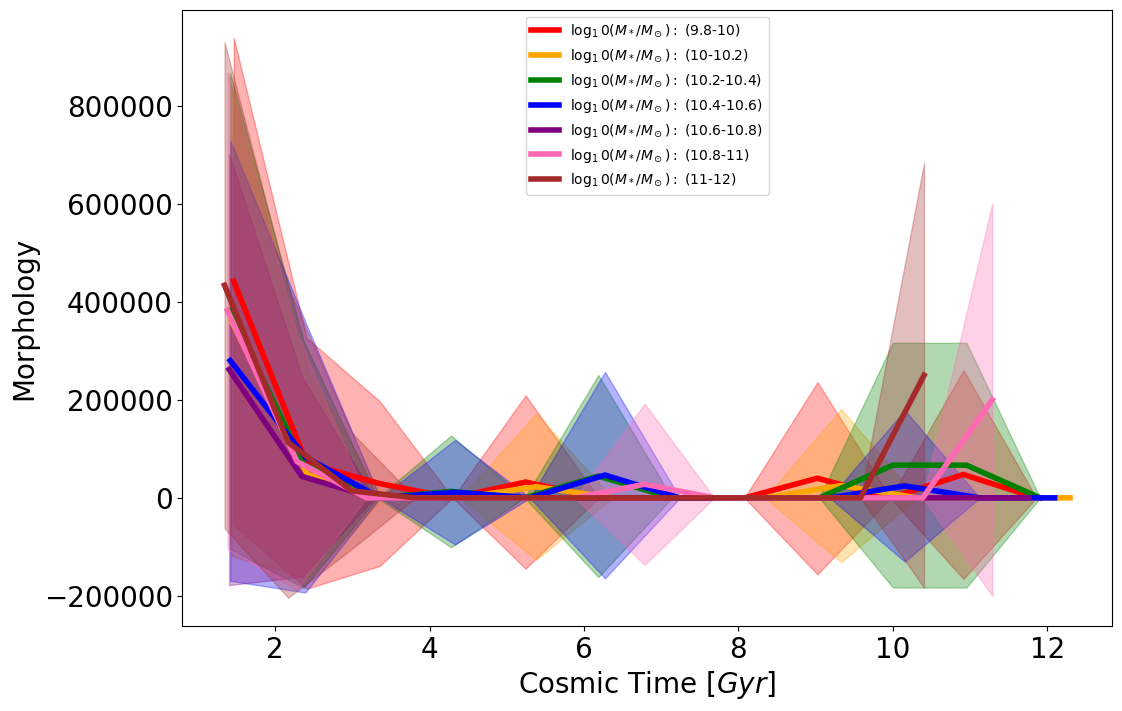

In [15]:
# Define your redshift bins and mass bins
nbins = 12
mass_bin = [[9.8,10],[10,10.2],[10.2,10.4],[10.4,10.6],[10.6,10.8],[10.8,11],[11,12]]
colors = ['red', 'orange', 'green', 'blue', 'purple', 'hotpink', 'brown']  # Adjust or add more colors for each mass bin 

plt.figure(figsize=[12, 8])
plt.tick_params(axis='both', which='major', labelsize=20)

# Loop through each mass bin and corresponding color
for m_bin, color in zip(mass_bin, colors):
    # Load node_features for the current mass bin
    with open(nfm_data_path + f'node_features_morphology{m_bin[0]}_{m_bin[1]}.pkl', 'rb') as infile:
        node_features = pickle.load(infile)
        
    all_sfrs = []
    all_redshifts = []

    # Assuming 'n_chunks' is the total number of entries for node_features['t']
    for i in range(len(node_features['t'])):
        redshifts = 1 / np.array(node_features['t'][i]) - 1
        cosmic_times = Planck15.age(redshifts).value  # Make sure to extract value if it's a Quantity
        morphology = np.array(node_features['morphology'][i])

        all_redshifts.extend(cosmic_times)
        all_sfrs.extend(morphology)

    # Processing for binned statistics
    all_redshifts_np = np.squeeze(np.array(all_redshifts))
    all_sfrs_np = np.squeeze(np.array(all_sfrs))

    # Filtering valid data
    valid_data_mask = ~np.isnan(all_redshifts_np) & ~np.isnan(all_sfrs_np)
    filtered_redshifts = all_redshifts_np[valid_data_mask]
    filtered_sfrs = all_sfrs_np[valid_data_mask]

    # Binning the data
    bin_means, bin_edges, _ = stats.binned_statistic(filtered_redshifts, filtered_sfrs, statistic='mean', bins=nbins)
    bin_stds, _, _ = stats.binned_statistic(filtered_redshifts, filtered_sfrs, statistic='std', bins=nbins)
    bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

    # Plotting mean and std deviation
    plt.plot(bin_centers, bin_means, color=color, label=rf"$\log_{10}(M_* / M_\odot):$ ({m_bin[0]}-{m_bin[1]})", lw=4)
    plt.fill_between(bin_centers, bin_means - bin_stds, bin_means + bin_stds, color=color, alpha=0.3)

# Replace numerical y-axis values with labels
#plt.yticks([0, 1, 2, 3], ['E', 'S', 'I', 'B+D'])

# Finalizing the plot
plt.xlabel('Cosmic Time [$Gyr$]', fontsize=20)
plt.ylabel('Morphology', fontsize=20)
plt.legend(loc='best')
plt.tight_layout
plt.savefig(plots_path+'morphology_evolution_cosmicyears.png')
plt.show()


In [16]:
"""# Setup for plotting and data
nbins = 12
mass_bin = [[9.8,10],[10,10.2],[10.2,10.4],[10.4,10.6],[10.6,10.8],[10.8,11],[11,12]]

colors = ['red', 'orange', 'green', 'blue', 'purple', 'hotpink', 'brown']  # Adjust or add more colors for each mass bin 
morphology_mapping = {0: 0, 3: 1, 1: 2, 2: 3}


plt.figure(figsize=[8, 8])
plt.tick_params(axis='both', which='major', labelsize=20)

for m_bin, color in zip(mass_bin, colors):
    with open(nfm_data_path + f'node_features_morphology{m_bin[0]}_{m_bin[1]}.pkl', 'rb') as infile:
        node_features = pickle.load(infile)
        
    all_morphologies = []
    all_cosmic_times = []

    for i in range(len(node_features['t'])):
        redshifts = 1 / np.array(node_features['t'][i]) - 1
        cosmic_times = Planck15.age(redshifts).value  # convert to Gyr
        morphologies = np.array(node_features['morphology'][i])
        remapped_morphologies = np.vectorize(morphology_mapping.get)(morphologies)  # Remap the morphologies

        all_cosmic_times.extend(cosmic_times)
        all_morphologies.extend(remapped_morphologies)

    all_cosmic_times_np = np.array(all_cosmic_times)
    all_morphologies_np = np.array(all_morphologies)

    valid_data_mask = ~np.isnan(all_cosmic_times_np) & ~np.isnan(all_morphologies_np)
    filtered_cosmic_times = all_cosmic_times_np[valid_data_mask]
    filtered_morphologies = all_morphologies_np[valid_data_mask]

    bin_means, bin_edges, _ = stats.binned_statistic(filtered_cosmic_times, filtered_morphologies, statistic='mean', bins=nbins)
    bin_stds, _, _ = stats.binned_statistic(filtered_cosmic_times, filtered_morphologies, statistic='std', bins=nbins)
    bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

    plt.plot(bin_centers, bin_means, color=color, label=rf"$\log_{10}(M_* / M_\odot):$ ({m_bin[0]}-{m_bin[1]})", lw=4)
    plt.fill_between(bin_centers, bin_means - bin_stds, bin_means + bin_stds, color=color, alpha=0.3)

# Set custom y-axis labels
morphology_labels = ['E', 'B+D', 'S', 'I']
plt.yticks(range(4), morphology_labels)

plt.xlabel('Cosmic Time [$Gyr$]', fontsize=20)
plt.ylabel('Morphology', fontsize=20)
plt.legend(loc='lower right', fontsize=12)
#plt.savefig(plots_path+'morphology_evolution_massbin.png')
plt.show()
"""

<>:39: SyntaxWarning: invalid escape sequence '\l'
<>:39: SyntaxWarning: invalid escape sequence '\l'
C:\Users\usuario\AppData\Local\Temp\ipykernel_10460\2934229873.py:39: SyntaxWarning: invalid escape sequence '\l'
  plt.plot(bin_centers, bin_means, color=color, label=rf"$\log_{10}(M_* / M_\odot):$ ({m_bin[0]}-{m_bin[1]})", lw=4)


'# Setup for plotting and data\nnbins = 12\nmass_bin = [[9.8,10],[10,10.2],[10.2,10.4],[10.4,10.6],[10.6,10.8],[10.8,11],[11,12]]\n\ncolors = [\'red\', \'orange\', \'green\', \'blue\', \'purple\', \'hotpink\', \'brown\']  # Adjust or add more colors for each mass bin \nmorphology_mapping = {0: 0, 3: 1, 1: 2, 2: 3}\n\n\nplt.figure(figsize=[8, 8])\nplt.tick_params(axis=\'both\', which=\'major\', labelsize=20)\n\nfor m_bin, color in zip(mass_bin, colors):\n    with open(nfm_data_path + f\'node_features_morphology{m_bin[0]}_{m_bin[1]}.pkl\', \'rb\') as infile:\n        node_features = pickle.load(infile)\n\n    all_morphologies = []\n    all_cosmic_times = []\n\n    for i in range(len(node_features[\'t\'])):\n        redshifts = 1 / np.array(node_features[\'t\'][i]) - 1\n        cosmic_times = Planck15.age(redshifts).value  # convert to Gyr\n        morphologies = np.array(node_features[\'morphology\'][i])\n        remapped_morphologies = np.vectorize(morphology_mapping.get)(morphologies) 

In [17]:
"""# Define your redshift bins and mass bins
bin_edges = np.array([0, 0.5, 1., 1.5, 2, 2.5, 3.5,4, 4.5,5,5.5, 6])
mass_bin = [[9.8,10],[10,10.2],[10.2,10.4],[10.4,10.6],[10.6,10.8],[10.8,11],[11,12]]
colors = ['red', 'orange', 'green', 'blue', 'purple', 'hotpink', 'brown']  # Adjust or add more colors for each mass bin 

plt.figure(figsize=[8, 8])
plt.tick_params(axis='both', which='major', labelsize=20)

# Loop through each mass bin and corresponding color
for m_bin, color in zip(mass_bin, colors):
    # Load node_features for the current mass bin
    with open(nfm_data_path+f'node_features_morphology{m_bin[0]}_{m_bin[1]}.pkl', 'rb') as infile:
        node_features = pickle.load(infile)
        
    all_sfrs = []
    all_redshifts = []

    # Assuming 'n_chunks' is the total number of entries for node_features['t']
    for i in range(len(node_features['t'])):
        redshifts = 1 / np.array(node_features['t'][i]) - 1
        sfr = np.array(node_features['x'][i][:, 2])
        ssfr = np.log10(10**np.array(node_features['x'][i][:, 2])/10**np.array(node_features['x'][i][:, 0]))
        #plt.plot(redshifts, ssfr, color=color, alpha=0.2)  # Use the same color for individual lines, with some alpha

        all_redshifts.extend(redshifts)
        all_sfrs.extend(ssfr)

    # Processing for binned statistics
    all_redshifts_np = np.squeeze(np.array(all_redshifts))
    all_sfrs_np = np.array(all_sfrs)

    # Filtering valid data
    valid_data_mask = ~np.isnan(all_redshifts_np) & ~np.isnan(all_sfrs_np)
    filtered_redshifts = all_redshifts_np #[valid_data_mask]
    filtered_sfrs = all_sfrs_np #[valid_data_mask]

    # Binning the data
    bin_means, _, _ = stats.binned_statistic(filtered_redshifts, filtered_sfrs, statistic='mean', bins=bin_edges)
    bin_stds, _, _ = stats.binned_statistic(filtered_redshifts, filtered_sfrs, statistic='std', bins=bin_edges)
    bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

    # Plotting mean and std deviation
    plt.plot(bin_centers, bin_means, color=color, label=rf"$\log_{10}(M_* / M_\odot):$ ({m_bin[0]}-{m_bin[1]})",lw=4)
    plt.fill_between(bin_centers, bin_means - bin_stds, bin_means + bin_stds, color=color, alpha=0.3)

# Finalizing the plot
plt.xlabel('Redshift', fontsize=20)
plt.ylabel('$\log$ SFR', fontsize=20)
plt.legend(loc='lower right')
#plt.savefig(plots_path+'log_sfr_redfshit_massbin.png')
plt.show()
"""

<>:43: SyntaxWarning: invalid escape sequence '\l'
<>:43: SyntaxWarning: invalid escape sequence '\l'
C:\Users\usuario\AppData\Local\Temp\ipykernel_10460\4046856441.py:43: SyntaxWarning: invalid escape sequence '\l'
  plt.plot(bin_centers, bin_means, color=color, label=rf"$\log_{10}(M_* / M_\odot):$ ({m_bin[0]}-{m_bin[1]})",lw=4)


'# Define your redshift bins and mass bins\nbin_edges = np.array([0, 0.5, 1., 1.5, 2, 2.5, 3.5,4, 4.5,5,5.5, 6])\nmass_bin = [[9.8,10],[10,10.2],[10.2,10.4],[10.4,10.6],[10.6,10.8],[10.8,11],[11,12]]\ncolors = [\'red\', \'orange\', \'green\', \'blue\', \'purple\', \'hotpink\', \'brown\']  # Adjust or add more colors for each mass bin \n\nplt.figure(figsize=[8, 8])\nplt.tick_params(axis=\'both\', which=\'major\', labelsize=20)\n\n# Loop through each mass bin and corresponding color\nfor m_bin, color in zip(mass_bin, colors):\n    # Load node_features for the current mass bin\n    with open(nfm_data_path+f\'node_features_morphology{m_bin[0]}_{m_bin[1]}.pkl\', \'rb\') as infile:\n        node_features = pickle.load(infile)\n\n    all_sfrs = []\n    all_redshifts = []\n\n    # Assuming \'n_chunks\' is the total number of entries for node_features[\'t\']\n    for i in range(len(node_features[\'t\'])):\n        redshifts = 1 / np.array(node_features[\'t\'][i]) - 1\n        sfr = np.array(nod

<>:50: SyntaxWarning: invalid escape sequence '\l'
<>:51: SyntaxWarning: invalid escape sequence '\l'
<>:50: SyntaxWarning: invalid escape sequence '\l'
<>:51: SyntaxWarning: invalid escape sequence '\l'
C:\Users\usuario\AppData\Local\Temp\ipykernel_10460\1782958555.py:50: SyntaxWarning: invalid escape sequence '\l'
  plt.xlabel('$\log_{10}(M_* / M_{\odot})$', fontsize=20)
C:\Users\usuario\AppData\Local\Temp\ipykernel_10460\1782958555.py:51: SyntaxWarning: invalid escape sequence '\l'
  plt.ylabel('$\log$ SFR', fontsize=20)


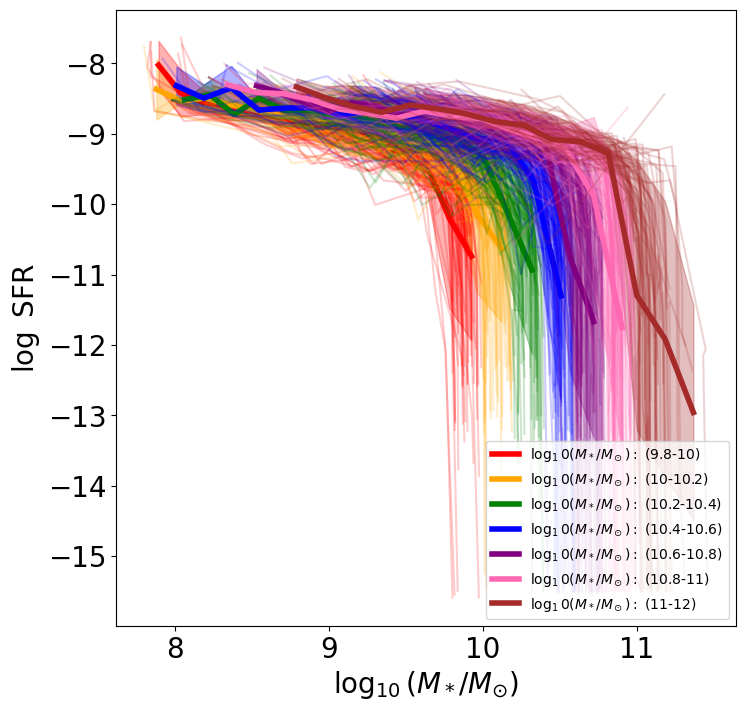

In [18]:
# Define your redshift bins and mass bins
#bin_edges = np.array([0, 0.5, 1., 1.5, 2, 2.5, 3.5, 4.5, 6])
nbins = 15
mass_bin = [[9.8,10],[10,10.2],[10.2,10.4],[10.4,10.6],[10.6,10.8],[10.8,11],[11,12]]

colors = ['red', 'orange', 'green', 'blue', 'purple', 'hotpink', 'brown']  # Adjust or add more colors for each mass bin 

plt.figure(figsize=[8, 8])
plt.tick_params(axis='both', which='major', labelsize=20)

# Loop through each mass bin and corresponding color
for m_bin, color in zip(mass_bin, colors):
    # Load node_features for the current mass bin
    with open(nfm_data_path+f'node_features_morphology{m_bin[0]}_{m_bin[1]}.pkl', 'rb') as infile:
        node_features = pickle.load(infile)
        
    all_sfrs = []
    all_redshifts = []

    # Assuming 'n_chunks' is the total number of entries for node_features['t']
    for i in range(len(node_features['t'])):
        redshifts = 1 / np.array(node_features['t'][i]) - 1
        sfr = np.array(node_features['x'][i][:, 2])
        mstar = np.array(node_features['x'][i][:, 0])
        ssfr = np.log10(10**np.array(node_features['x'][i][:, 2])/10**np.array(node_features['x'][i][:, 0]))
        plt.plot(mstar, ssfr, color=color, alpha=0.2)  # Use the same color for individual lines, with some alpha

        all_redshifts.extend(mstar)
        all_sfrs.extend(ssfr)

    # Processing for binned statistics
    all_redshifts_np = np.squeeze(np.array(all_redshifts))
    all_sfrs_np = np.array(all_sfrs)

    # Filtering valid data
    #valid_data_mask = ~np.isnan(all_redshifts_np) & ~np.isnan(all_sfrs_np)
    filtered_redshifts = all_redshifts_np
    filtered_sfrs = all_sfrs_np

    # Binning the data
    bin_means, bin_edges, _ = stats.binned_statistic(filtered_redshifts, filtered_sfrs, statistic='mean', bins=nbins)
    bin_stds, _, _ = stats.binned_statistic(filtered_redshifts, filtered_sfrs, statistic='std', bins=nbins)
    bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

    # Plotting mean and std deviation
    plt.plot(bin_centers, bin_means, color=color, label=rf"$\log_{10}(M_* / M_\odot):$ ({m_bin[0]}-{m_bin[1]})",lw=4)
    plt.fill_between(bin_centers, bin_means - bin_stds, bin_means + bin_stds, color=color, alpha=0.3)

# Finalizing the plot
plt.xlabel('$\log_{10}(M_* / M_{\odot})$', fontsize=20)
plt.ylabel('$\log$ SFR', fontsize=20)
plt.legend(loc='lower right')
plt.savefig(plots_path+'log_sfr_log_mass_combined.png')
plt.show()


<>:50: SyntaxWarning: invalid escape sequence '\l'
<>:51: SyntaxWarning: invalid escape sequence '\l'
<>:50: SyntaxWarning: invalid escape sequence '\l'
<>:51: SyntaxWarning: invalid escape sequence '\l'
C:\Users\usuario\AppData\Local\Temp\ipykernel_10460\1571036142.py:50: SyntaxWarning: invalid escape sequence '\l'
  plt.xlabel('$\log_{10}(M_* / M_{\odot})$', fontsize=20)
C:\Users\usuario\AppData\Local\Temp\ipykernel_10460\1571036142.py:51: SyntaxWarning: invalid escape sequence '\l'
  plt.ylabel('$\log R_e$', fontsize=20)


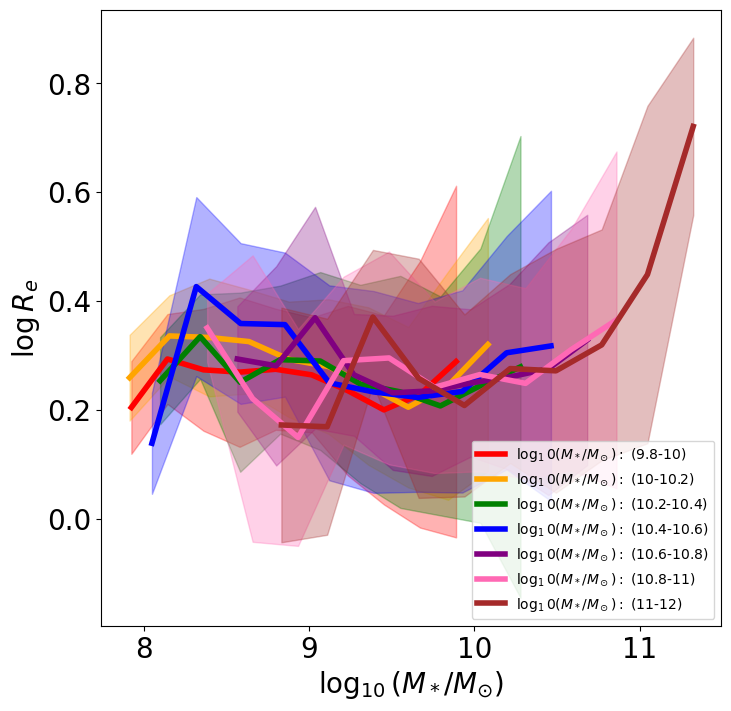

In [19]:
# Define your redshift bins and mass bins
#bin_edges = np.array([0, 0.5, 1., 1.5, 2, 2.5, 3.5, 4.5, 6])
nbins = 10
mass_bin = [[9.8,10],[10,10.2],[10.2,10.4],[10.4,10.6],[10.6,10.8],[10.8,11],[11,12]]
colors = ['red', 'orange', 'green', 'blue', 'purple', 'hotpink', 'brown']  # Adjust or add more colors for each mass bin 

plt.figure(figsize=[8, 8])
plt.tick_params(axis='both', which='major', labelsize=20)

# Loop through each mass bin and corresponding color
for m_bin, color in zip(mass_bin, colors):
    # Load node_features for the current mass bin
    with open(nfm_data_path+f'node_features_morphology{m_bin[0]}_{m_bin[1]}.pkl', 'rb') as infile:
        node_features = pickle.load(infile)
        
    all_sfrs = []
    all_redshifts = []

    # Assuming 'n_chunks' is the total number of entries for node_features['t']
    for i in range(len(node_features['t'])):
        redshifts = 1 / np.array(node_features['t'][i]) - 1
        sfr = np.array(node_features['x'][i][:, 2])
        re = np.array(node_features['x'][i][:, 1])
        mstar = np.array(node_features['x'][i][:, 0])
        ssfr = np.log10(10**np.array(node_features['x'][i][:, 2])/10**np.array(node_features['x'][i][:, 0]))
        #plt.plot(mstar, ssfr, color=color, alpha=0.2)  # Use the same color for individual lines, with some alpha

        all_redshifts.extend(mstar)
        all_sfrs.extend(re)

    # Processing for binned statistics
    all_redshifts_np = np.squeeze(np.array(all_redshifts))
    all_sfrs_np = np.array(all_sfrs)

    # Filtering valid data
    #valid_data_mask = ~np.isnan(all_redshifts_np) & ~np.isnan(all_sfrs_np)
    filtered_redshifts = all_redshifts_np
    filtered_sfrs = all_sfrs_np

    # Binning the data
    bin_means, bin_edges, _ = stats.binned_statistic(filtered_redshifts, filtered_sfrs, statistic='mean', bins=nbins)
    bin_stds, _, _ = stats.binned_statistic(filtered_redshifts, filtered_sfrs, statistic='std', bins=nbins)
    bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

    # Plotting mean and std deviation
    plt.plot(bin_centers, bin_means, color=color, label=rf"$\log_{10}(M_* / M_\odot):$ ({m_bin[0]}-{m_bin[1]})",lw=4)
    plt.fill_between(bin_centers, bin_means - bin_stds, bin_means + bin_stds, color=color, alpha=0.3)

# Finalizing the plot
plt.xlabel('$\log_{10}(M_* / M_{\odot})$', fontsize=20)
plt.ylabel('$\log R_e$', fontsize=20)
plt.legend(loc='lower right')
plt.savefig(plots_path+'log_re_log_mass_combined.png')
plt.show()


#### Comparing with {ID}_SFH.fits

Using {ID}_SFH.fits (I don't have these files)

In [20]:
file_list = []
mass_bin = [[9.8, 10], [10, 10.2], [10.2, 10.4], [10.4, 10.6], [10.6, 10.8], [10.8, 11], [11, 12]]

# Generate the list of file names based on node_features['id']
for m_bin in mass_bin:
    # Load node_features for the current mass bin
    with open(os.path.join(nfm_data_path, f'node_features_morphology{m_bin[0]}_{m_bin[1]}.pkl'), 'rb') as infile:
        node_features = pickle.load(infile)
        
    for i in range(len(node_features['x'])):
        id_val = node_features['id'][i][0, 0]  # Ensure this is how your ID is structured
        file_name = f"{id_val}_SFH.fits"
        file_list.append(file_name)

# Generate a single string of file names separated by spaces for the tar command
file_list_str = ' '.join([datos2_data_path + file for file in file_list])

# Create the command to generate a tarball
tar_command = f"tar -czvf collected_files.tar.gz {file_list_str}"

# Write the command to a shell script file
script_file_name = "create_tarball.sh"
with open(nfm_data_path+script_file_name, 'w') as script_file:
    script_file.write("#!/bin/bash\n")
    script_file.write(tar_command + "\n")

# Make the script executable
os.chmod(nfm_data_path+script_file_name, 0o755)

print(f"The tar command has been saved in {script_file_name}")


The tar command has been saved in create_tarball.sh


In [21]:
# Define your redshift bins and mass bins
nbins=12
bin_edges = np.array([0, 0.5, 1., 1.5, 2, 2.5, 3.5, 4.5, 6])
mass_bin = [[9.8,10],[10,10.2],[10.2,10.4],[10.4,10.6],[10.6,10.8],[10.8,11],[11,12]]
#colors = ['blue', 'green', 'purple', 'orange','pink','brown','black']  # Adjust or add more colors for each mass bin

#SFH_path = "/Users/marchuertascompany/Documents/data/COSMOS-Web/automnt/n17data/arango/CIGALE/runs/run_web/COSMOSWEB_1.6_INPUT/out/" 
SFH_path = datos2_data_path
#### Para mi sfh_path es el path a datos2

plt.figure(figsize=[8, 8])
plt.tick_params(axis='both', which='major', labelsize=20)

# Loop through each mass bin and corresponding color
for m_bin, color in zip(mass_bin, colors):
    # Load node_features for the current mass bin
    with open(nfm_data_path+f'node_features_morphology{m_bin[0]}_{m_bin[1]}.pkl', 'rb') as infile:
        node_features = pickle.load(infile)
        
    all_sfrs = []
    all_redshifts = []
   

    # Assuming 'n_chunks' is the total number of entries for node_features['t']
    for i in range(1):
        redshifts = 1 / np.array(node_features['t'][i]) - 1
        print(redshifts)
        t = np.array(node_features['t'][i])
        cosmic_times = Planck15.age(redshifts)
        sfr = 10**np.array(node_features['x'][i][:, 2])

        id_val = node_features['id'][i][0, 0]  # Ensure this is how your ID is structured
        print(id_val)
        file_name = f"{id_val}_SFH.fits"
        with fits.open(datos2_data_path+file_name) as hdul:
            data = hdul[1].data  # Assuming the table is in the first extension; adjust if different

            # Convert to a Pandas DataFrame
            sfh_fit = pd.DataFrame({ 'time': data['time'], 'SFR': data['SFR'] })
            print(sfh_fit.time.values)
        plt.plot(cosmic_times, sfr, color='black',label='Florah')  # Use the same color for individual lines, with some alpha
        plt.plot(sfh_fit.time.values*1e-3+cosmic_times[0].value-len(sfh_fit.time.values)*1e-3,sfh_fit.SFR.values,color='red',label='SED fit')
       

        # Finalizing the plot
        plt.xlabel('Cosmic Time [$Gyr$]', fontsize=20)
        plt.ylabel('SFR ($M_\odot.yr^{-1}$)', fontsize=20)
        plt.legend(loc='upper right',fontsize=15)
        plt.savefig(plots_path+'sfr_growth_CEERS_combined.png')
        plt.show()
"""

<>:47: SyntaxWarning: invalid escape sequence '\o'
<>:47: SyntaxWarning: invalid escape sequence '\o'
C:\Users\usuario\AppData\Local\Temp\ipykernel_10460\596692934.py:47: SyntaxWarning: invalid escape sequence '\o'
  plt.ylabel('SFR ($M_\odot.yr^{-1}$)', fontsize=20)


_IncompleteInputError: incomplete input (596692934.py, line 51)

### graficas chiquitas de nuevo


In [ ]:
print(np.array(node_features['x']).shape)
node_features['t'][0]

for i in range(51):
    plt.plot(np.array(node_features['x'][i][:,0]),np.array(node_features['x'][i][:,2]))

plt.xlabel('$\log_{10}(M_* / M_{\odot})$',fontsize=20)

plt.ylabel('$\log SFR$',fontsize=20)

plt.savefig(plots_path+'logsfr_logmass.png')

In [ ]:
print(np.array(node_features['x']).shape)
node_features['t'][0]

for i in range(51):
    ssfr = np.log10(10**np.array(node_features['x'][i][:,2])/10**np.array(node_features['x'][i][:,0]))
    plt.plot(np.array(node_features['x'][i][:,0]),ssfr)

plt.xlabel('$ M_*/M_\odot$',fontsize=20)

plt.ylabel('$SFR$',fontsize=20)

plt.savefig(plots_path+'sfr_mass_combined.png')

In [ ]:
print(np.array(node_features['x']).shape)
node_features['t'][0]

for i in range(80):
    plt.plot(1/ np.array(node_features['t'][i]) - 1 ,10**np.array(node_features['x'][i][:,0])/10**np.array(node_features['x'][i][0,0]))

plt.xlabel('redshift',fontsize=20)

plt.ylabel('$\log M_*$',fontsize=20)


print(node_features['ra'][11][0][0])
print(node_features['dec'][11][0])

plt.savefig(plots_path+'mass_growth2.png')

In [ ]:
print(np.array(node_features['x']).shape)
node_features['t'][0]

for i in range(10):
    plt.plot(1/ np.array(node_features['t'][i]) - 1,np.array(node_features['x'][i][:,1]))

plt.xlabel('redshift',fontsize=20)

plt.ylabel('$\log R_e$',fontsize=20)    

In [ ]:
print(np.array(node_features['x']).shape)
node_features['t'][0]

for i in range(1):
    plt.plot(1/ np.array(node_features['t'][i]) - 1,np.array(node_features['x'][i][:,2]))

plt.xlabel('redshift',fontsize=20)

plt.ylabel('$\log SFR$',fontsize=20)      

In [ ]:
print(np.array(node_features['x']).shape)
node_features['t'][0]

for i in range(20):
    plt.plot(np.array(node_features['x'][i][:,0]),np.array(node_features['x'][i][:,2]))

plt.xlabel('$\log_{10}(M_* / M_{\odot})$',fontsize=20)

plt.ylabel('$\log SFR$',fontsize=20)    

In [ ]:
print(np.array(node_features['x']).shape)
node_features['t'][0]

for i in range(20):
    plt.plot(np.array(node_features['x'][i][:,0]),np.array(node_features['x'][i][:,1]))


plt.xlabel('$\log_{10}(M_* / M_{\odot})$',fontsize=20)

plt.ylabel('$\log Re$',fontsize=20)   

## A partir de aquí mirar:

In [ ]:
q = cosmos_cat.query('ra>=214.88161 and ra<=214.88163 and dec>=52.88396 and dec<=52.88398') ###### RA_1 = ra, DEC_1 = dec
q = cosmos_cat.query('ra>='+str(node_features['ra'][i][0][0]-1e-5)+' and ra<='+str(node_features['ra'][i][0][0]+1e-5)+' and dec>='+str(node_features['dec'][i][0][0]-1e-5)+' and dec<='+str(node_features['ra'][i][0][0]+1e-5))
print(q.id)

In [ ]:
"""densebasis_dir = '/Users/marchuertascompany/Documents/data/CEERS/DenseBasis/'
db_cat = pd.read_csv(densebasis_dir + "CEERS_v0.51_dense_basis.csv")



#os.listdir(densebasis_dir)
#db_cat = Table.read(densebasis_dir + "CEERS_v0.51_dense_basis.fits", format='ascii.commented_header')

""" ##### Cambiar datos por los de cosmos

In [ ]:
from astropy.cosmology import Planck13,z_at_value
import astropy.units as u

cosmos_sel = cosmos_cat.query('id == 19566')
sfh=cosmos_sel.sfh_50.values[0] # ????
time = cosmos_sel.timeax.values[0]

# Remove the parentheses and split the string by comma
sfh = sfh.strip('()').split(',')
time = time.strip('()').split(',')

# Convert the strings to float numbers
numbers = [float(num) for num in sfh]
numbers_time = [float(num) for num in time]

# Convert the list of numbers to a NumPy array
sfh_array = np.array(numbers)
time_array = np.array(numbers_time)



cosmo = Planck13

# Convert time to redshift
# Convert time to redshift

print(cosmo.age)

redshift_array = np.array([z_at_value(cosmo.age, (t) * u.Gyr) for t in time_array[1:]])

sfh_array = sfh_array[1:]
plt.plot(redshift_array[redshift_array<5],np.log10(sfh_array[redshift_array<5]))

print(np.array(node_features['x']).shape)
node_features['t'][0]


plt.plot(1/ np.array(node_features['t'][11]) - 1,np.array(node_features['x'][11][:,2]))

plt.xlabel('redshift',fontsize=20)

plt.ylabel('$\log SFR$',fontsize=20)  

In [ ]:
from astropy.cosmology import Planck13, z_at_value
import astropy.units as u



# Create a 2x5 grid of subplots (10 panels)
fig, axs = plt.subplots(2, 5, figsize=(15, 6))

first_obj = 68

for i in range(10):
    q = cosmos_cat.query(
        'RA_1>=' + str(node_features['ra'][first_obj+i][0][0] - 1e-5) + ' and RA_1<=' + str(node_features['ra'][first_obj+i][0][0] + 1e-5) +
        ' and DEC_1>=' + str(node_features['dec'][first_obj+i][0][0] - 1e-5) + ' and DEC_1<=' + str(node_features['dec'][first_obj+i][0][0] + 1e-5))


    print(q['ID_1'].values)
    cosmos_sel = cosmos_cat.query('ID == ' + str(q['ID_1'].values[0]))
    sfh = cosmos_sel.sfh_50.values[0]
    sfh_16 = cosmos_sel.sfh_16.values[0]
    sfh_84 = cosmos_sel.sfh_84.values[0]
    time = cosmos_sel.timeax.values[0]

    # Remove the parentheses and split the string by comma
    sfh = sfh.strip('()').split(',')
    sfh_16 = sfh_16.strip('()').split(',')
    sfh_84 = sfh_84.strip('()').split(',')
    time = time.strip('()').split(',')

    # Convert the strings to float numbers
    numbers = [float(num) for num in sfh]
    numbers_16 = [float(num) for num in sfh_16]
    numbers_84 = [float(num) for num in sfh_84]
    numbers_time = [float(num) for num in time]

    # Convert the list of numbers to a NumPy array
    sfh_array = np.array(numbers)
    sfh_array_16 = np.array(numbers_16)
    sfh_array_84 = np.array(numbers_84)
    time_array = np.array(numbers_time)

    cosmo = Planck13

    # Convert time to redshift
    redshift_array = np.array([z_at_value(cosmo.age, t * u.Gyr) for t in time_array[1:]])

    sfh_array = sfh_array[1:]
    #print(sfh_array[1:])
    sfh_array_16 = sfh_array_16[1:]
    sfh_array_84 = sfh_array_84[1:]

    # Determine the subplot location in the 2x5 grid
    row = i // 5
    col = i % 5

    # Plot the data on the current subplot
    #axs[row, col].plot(redshift_array[redshift_array < 5], np.log10(sfh_array[redshift_array < 5]))
    axs[row, col].fill_between(redshift_array[redshift_array < 6], np.log10(sfh_array_16[redshift_array < 6]),np.log10(sfh_array_84[redshift_array < 6]),color='red',alpha=0.5,label='DenseBasis')
    axs[row, col].set_title(f'ID '+str(q['ID_1'].values[0]))
    axs[row, col].plot(1/ np.array(node_features['t'][first_obj+i]) - 1,np.array(node_features['x'][first_obj+i][:,2]),lw=4,color='black',label='Florah')
    axs[row, col].legend(loc='lower right')
    axs[row, col].set_ylim((-4,2.5))
# Set common labels for the entire figure
fig.text(0.5, 0.001, 'Redshift', ha='center', fontsize=20)
fig.text(0.001, 0.5, '$\log SFR$', va='center', rotation='vertical', fontsize=20)

# Adjust subplot layout and show the figure
plt.tight_layout()
plt.savefig('SFH_comparisons.png')
plt.show()


In [ ]:
import astropy.units as u
from astropy.coordinates import SkyCoord
from astropy.coordinates import match_coordinates_sky

c = SkyCoord(ra=ra1*u.degree, dec=dec1*u.degree)